# Modeling Safe Detection Distance for Road Hazard Prevention Under Low Visibility Conditions

### A Physics-Based Analysis with Real-World Constraints on Visibility and Driver Response

## Problem Statement
In low visibility conditions, drivers may not detect hazards in time to stop safely. 
This creates a mismatch between visible distance and required stopping distance, leading to accidents.

This study evaluates whether safe stopping is physically achievable under realistic visibility constraints.

## Motivation and Real-World Context
Road accident reports in India indicate that a significant proportion of crashes occur under low visibility conditions such as fog and nighttime driving. Limited visibility reduces the distance at which drivers can detect hazards, leading to delayed reaction and increased stopping distance requirements.

Government road safety reports(e.g., MoRTH, NCRB) consistently highlight visibility-related risks as a contributing factor in accidents, especially in fog-prone regions. This highlights the importance of understanding the relationship between detection distance and stopping capability.

This study focuses on analyzing whether drivers can physically stop in time under such constrained visibility conditions.

## Indian Context and Relevance

Low-visibility conditions are particularly critical in India, especially in North Indian highway corridors where dense winter fog frequently leads to multi-vehicle collisions.

Such incidents highlight the practical importance of understanding whether safe stopping is physically achievable under constrained visibility.

## Model Overview
Stopping distance consists of two components:

- Reaction Distance: Distance traveled during driver reaction time
- Braking Distance: Distance required to stop after brakes are applied

Stopping Distance = Reaction Distance + Braking Distance

This model evaluates stopping distance under varying speeds and conditions to determine safe detection requirements.

This model is evaluated under realistic driving parameters and visibility 

## Model Formulation

We define:

- Speed (v) in m/s  
- Reaction Time (t) in seconds  
- Friction Coefficient (μ)  
- Gravitational Acceleration (g = 9.81 m/s²)

### Formulas:

Reaction Distance = v × t  
Braking Distance = v² / (2 × μ × g)  

Stopping Distance = Reaction Distance + Braking Distance

## Assumption Justification

The model uses parameters based on realistic driving conditions:

- **Reaction Time:**  
  Human reaction time in driving scenarios typically ranges between 0.8 to 1.5 seconds, depending on alertness and environmental conditions. This range is widely referenced in traffic safety studies.

- **Friction Coefficient (μ):**  
  Road-tire friction varies based on surface conditions:
  - Dry road ≈ 0.7  
  - Wet road ≈ 0.4  
  These values are consistent with standard vehicle dynamics and braking behavior references.

- **Gravitational Acceleration (g):**  
  A constant value of 9.81 m/s² is used.

- **Simplifying Assumptions:**  
  - Flat road surface  
  - Constant vehicle speed before braking  
  - No external disturbances (e.g., slope, wind)

These assumptions allow controlled analysis while remaining consistent with real-world driving conditions.

In [1]:
# unit conversion kmh to ms

def kmh_to_ms(speed_kmh):
    return speed_kmh * (1000/3600)

In [2]:
def reaction_distance(speed_ms, reaction_time):
    return speed_ms * reaction_time

def braking_distance(speed_ms, friction, g=9.81):
    return (speed_ms ** 2) / (2*friction*g)

def stopping_distance(speed_kmh, reaction_time, friction):
    speed_ms = kmh_to_ms(speed_kmh)
    rd = reaction_distance(speed_ms, reaction_time)
    bd = braking_distance(speed_ms, friction)
    return rd + bd

## Simulation Setup

To analyze stopping behavior under different conditions, we simulate stopping distance across:

- Multiple speeds (20 to 100 km/h)
- Different reaction times
- Different road conditions (dry and wet)

This helps identify patterns and unsafe scenarios.

In [3]:
import pandas as pd

speeds = list(range(20,101,10)) # 20 to 100 km/hr
reaction_times = [0.8, 1.0, 1.2, 1.5]

friction_conditions = {
    "Dry" : 0.7,
    "Wet" : 0.4
}

In [4]:
data = []

for condition, friction in friction_conditions.items():
    for rt in reaction_times:
        for speed in speeds:
            sd = stopping_distance(speed,rt,friction)
            data.append({"Speed (km/h)": speed, "Reaction Time (s)": rt, "Condition": condition, "Stopping Distance (m)": sd})

df = pd.DataFrame(data)

# Filter correctly
df_clean_filtered = df[
    (df["Speed (km/h)"].isin([20, 40, 60, 80, 100])) &
    (df["Reaction Time (s)"] == 1.0)
].copy()

# Pivot
df_pivot = df_clean_filtered.pivot(
    index="Speed (km/h)",
    columns="Condition",
    values="Stopping Distance (m)"
).reset_index()

# Clean column names
df_pivot.columns.name = None
df_pivot = df_pivot.rename(columns={
    "Dry": "Dry (m)",
    "Wet": "Wet (m)"
})

# Add reaction time column manually
df_pivot["Reaction Time (s)"] = 1.0

# Reorder columns
df_pivot = df_pivot[
    ["Speed (km/h)", "Reaction Time (s)", "Dry (m)", "Wet (m)"]
]

# Round values
df_pivot["Dry (m)"] = df_pivot["Dry (m)"].round(1)
df_pivot["Wet (m)"] = df_pivot["Wet (m)"].round(1)

# Display clean table
df_pivot.style.format({
    "Reaction Time (s)": "{:.1f}",
    "Dry (m)": "{:.1f}",
    "Wet (m)": "{:.1f}"
}).hide(axis="index")

Speed (km/h),Reaction Time (s),Dry (m),Wet (m)
20,1.0,7.8,9.5
40,1.0,20.1,26.8
60,1.0,36.9,52.1
80,1.0,58.2,85.1
100,1.0,84.0,126.1


#### This comparison shows that wet road conditions significantly increase stopping distance, reducing safe speed thresholds under low visibility.

## Visualization: Stopping Distance vs Visibility Constraints

This graph compares stopping distance with real-world visibility conditions:

- 20m -> Dense fog
- 40m -> Moderate fog
- 70m -> Low visibility night

The interaction of these with stopping distance curves indicate safe and unsafe driving conditions.

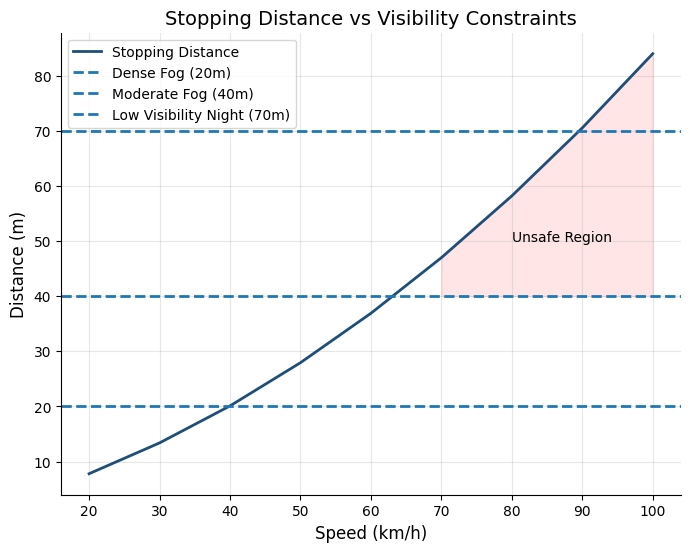

In [5]:
import matplotlib.pyplot as plt

df_dry = df[(df["Condition"] == "Dry") & (df["Reaction Time (s)"] == 1.0)]

speeds = df_dry["Speed (km/h)"]
stopping = df_dry["Stopping Distance (m)"]

plt.figure(figsize=(8,6))

# Stopping distance curve
plt.plot(speeds, stopping, linewidth=2, label="Stopping Distance", color='#1f4e79')

# Visibility lines
plt.axhline(y=20, linestyle='--', linewidth=2, label="Dense Fog (20m)")
plt.axhline(y=40, linestyle='--', linewidth=2, label="Moderate Fog (40m)")
plt.axhline(y=70, linestyle='--', linewidth=2, label="Low Visibility Night (70m)")

plt.fill_between(speeds, 40, stopping, where=(stopping > 40), alpha=0.1, color="red")

plt.text(80, 50, "Unsafe Region", fontsize=10)

plt.xlabel("Speed (km/h)", fontsize=12)
plt.ylabel("Distance (m)", fontsize=12)
plt.title("Stopping Distance vs Visibility Constraints", fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

## Graph Interpretation

The graph illustrates the relationship between vehicle speed and stopping distance under realistic driving conditions.

It shows that as speed increases, stopping distance rises non-linearly, meaning higher speeds require significantly greater distance to safely halt the vehicle.

When compared with typical visibility ranges (e.g., 20m in dense fog, 40m in moderate fog, and 70m in low-visibility night conditions), it becomes evident that beyond certain speeds, the required stopping distance exceeds the distance a driver can see.

This creates conditions where hazard detection occurs too late for effective braking, making safe stopping physically impossible.

## Visibility Constraints in Real-World Driving

Driver visibility is significantly reduced under certain conditions:

- **Dense fog:** approximately 20–50 meters  
- **Moderate fog:** approximately 40 meters  
- **Low visibility night driving:** approximately 60–80 meters  

These values represent typical observed visibility ranges on roads under adverse conditions.

When visibility distance is less than the required stopping distance, the driver may not be able to react in time to avoid a collision.

## Key Insights

1. Stopping distance increases non-linearly with speed, creating rapidly rising braking requirements at higher speeds.

2. Under dense fog (~20 m visibility), safe stopping is limited to ≈40 km/h; beyond this, stopping distance exceeds visibility.

3. Under moderate fog (~40 m), the safe threshold is ≈60 km/h.

4. Under low-visibility night (~70 m), the safe threshold is ≈90 km/h.

5. Across conditions, a consistent mismatch emerges between human perception limits (reaction time), environmental constraints (visibility), and vehicle dynamics (braking distance).

6. When stopping distance exceeds visibility, collision avoidance becomes physically impossible, regardless of driver intent.

7. Under wet road conditions, stopping distance increases further, reducing safe speed thresholds under low visibility.

## Recommended Safe Speed Limits

Based on the analysis:

- Dense fog (~20 m visibility): ≤ 40 km/h  
- Moderate fog (~40 m visibility): ≤ 60 km/h  
- Low-visibility night (~70 m visibility): ≤ 90 km/h  

These thresholds represent the maximum speeds at which stopping distance remains within visible range.

## Policy Implications and Technical Implementation

- *Dynamic Speed Regulation:*  
  Deploy Variable Message Signs (VMS) on fog-prone highways to display visibility-based speed limits in real time.

- *Visibility Monitoring Infrastructure:*  
  Install roadside sensors to measure visibility and environmental conditions continuously.

- *Edge-Based Processing:*  
  Use localized computing systems to convert visibility data into safe speed thresholds using the model developed in this study.

- *Driver Alert Systems:*  
  Integrate visual warning systems to alert drivers when visibility falls below safe thresholds.

Edge-based systems can be implemented using lightweight backend frameworks (e.g., FastAPI) to ingest real-time visibility sensor data and compute safe speed thresholds locally.

These systems can integrate with machine learning models or rule-based engines to dynamically adjust speed advisories with minimal latency.

These interventions translate physical safety constraints into real-time, technology-driven traffic management systems.

## Supporting Real-World Evidence

Empirical data from the MoRTH 'Road Accidents in India 2022' report provides a critical baseline for this study, noting that adverse weather—specifically fog and mist—contributed to a 9.1% increase in road fatalities. Our simulation highlights a systemic gap in current highway infrastructure: during peak-risk hours (18:00–21:00), standard speed limits require stopping distances that physically exceed human visual range. This project proposes a FastAPI-based Dynamic Speed Regulation architecture to bridge this gap between vehicle kinematics and real-time environmental visibility.

## Limitations

- The model assumes constant vehicle speed and does not account for variations in driver behavior or braking response.

- Road conditions are simplified into dry and wet categories; factors such as tire condition, road texture, and slope are not considered.

- Visibility values are based on typical observed ranges and may vary across different real-world scenarios.

- The study uses limited empirical references for contextual grounding and does not perform detailed statistical analysis on large-scale accident datasets.

Despite these limitations, the model captures the fundamental physical relationship between stopping distance and visibility constraints.

## Conclusion

This study demonstrates that safe driving is fundamentally constrained by the relationship between stopping distance and visibility.

Using realistic assumptions for reaction time, road conditions, and visibility ranges, the analysis shows that there exist common driving scenarios where the required stopping distance exceeds the distance a driver can see.

In such conditions, safe stopping becomes physically impossible, highlighting a structural limitation in human driving under low visibility environments.

#### These findings are particularly relevant for fog-prone regions in North India, where multi-vehicle collisions on highways such as NH-44 and the Yamuna Expressway are frequently reported.

#### This analysis suggests that under certain conditions, road accidents are not caused by driver error, but by unavoidable physical constraints.

## References

- Ministry of Road Transport and Highways (MoRTH), Road Accidents in India 2022.

- AASHTO, A Policy on Geometric Design of Highways and Streets.

- PIARC, Road Safety and Human Factors guidelines.

## Technical Note

The simulation was implemented using Python to evaluate stopping distance across multiple scenarios.

Code implementation is available at github.com/kunal.639